In [ ]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [ ]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 16.9 MB/s eta 0:00:00


In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection

100% 9.51G/9.51G [01:24<00:00, 121MB/s]



In [ ]:
!unzip -q aptos2019-blindness-detection.zip -d aptos_data
!rm aptos2019-blindness-detection.zip

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/aptos_data/train.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    3662 non-null   object
 1   diagnosis  3662 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 57.3+ KB


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
from PIL import Image

train_df,test_df = train_test_split(df,test_size=0.2,random_state=42,stratify=df["diagnosis"])

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2929 entries, 2579 to 3023
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    2929 non-null   object
 1   diagnosis  2929 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 68.6+ KB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 733 entries, 1595 to 1017
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    733 non-null    object
 1   diagnosis  733 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 17.2+ KB


In [ ]:
import os
from PIL import Image
from tqdm import tqdm

os.makedirs('aptos_data/train_images_resized', exist_ok=True)
os.makedirs('aptos_data/test_images_resized', exist_ok=True)

# Resize train images
for img_id in tqdm(train_df['id_code'], desc="Resizing train images"):
    img_path = f'aptos_data/train_images/{img_id}.png'
    img = Image.open(img_path).convert('RGB')
    img = img.resize((224, 224))
    img.save(f'aptos_data/train_images_resized/{img_id}.png')

# Resize test images (your held-out validation split, same source folder)
for img_id in tqdm(test_df['id_code'], desc="Resizing test images"):
    img_path = f'aptos_data/train_images/{img_id}.png'
    img = Image.open(img_path).convert('RGB')
    img = img.resize((224, 224))
    img.save(f'aptos_data/test_images_resized/{img_id}.png')

Resizing train images:   1%|          | 30/2929 [00:05<08:11,  5.90it/s]


KeyboardInterrupt: 

In [ ]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.15)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class APTOSDataset(Dataset):
  def __init__(self,df,img_dir,transform=None):
    super().__init__()
    self.data = df
    self.img_dir= img_dir
    self.transform = transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    img_id = self.data.iloc[index]["id_code"]
    label = self.data.iloc[index]["diagnosis"]
    img_path = os.path.join(self.img_dir,img_id+".png")
    image = Image.open(img_path).convert("RGB")
    if self.transform:
      image = self.transform(image)
    return image,label

In [ ]:
train_dataset = APTOSDataset(train_df, 'aptos_data/train_images_resized', train_transform)
test_dataset = APTOSDataset(test_df, 'aptos_data/test_images_resized', test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

**CNN FROM SCRATCH**

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class Mymodel(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1)
    self.conv2 = nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1)
    self.conv3 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1)
    self.conv4 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=1,padding=1)

    self.relu = nn.ReLU()

    self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

    self.flatten = nn.Flatten()

    self.fc = nn.Linear(128*56*56,5)

  def forward(self,x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv3(x)
    x = self.relu(x)
    x = self.conv4(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.flatten(x)
    x = self.fc(x)

    return x

In [ ]:
model = Mymodel()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")
loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(),lr=0.01)

Using device: cuda


In [ ]:
for epoch in range(10):
  model.train()
  total_loss = 0
  for image,label in train_loader:
    image, label = image.to(device), label.to(device)
    optimizer.zero_grad()
    prediction = model(image)
    loss = loss_function(prediction,label)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  average_loss = total_loss/len(train_loader)
  print(f"For Epoch{epoch+1} Loss {average_loss:.4f}")

For Epoch1 Loss 6.9302
For Epoch2 Loss 1.3725
For Epoch3 Loss 1.3554
For Epoch4 Loss 1.3558
For Epoch5 Loss 1.3543
For Epoch6 Loss 1.3547
For Epoch7 Loss 1.3562
For Epoch8 Loss 1.3551
For Epoch9 Loss 1.3564
For Epoch10 Loss 1.3558


In [ ]:
model.eval()
total= 0
correct = 0
with torch.no_grad():
  for image,label in test_loader :
    image, label = image.to(device), label.to(device)
    output = model(image)
    prediction = torch.argmax(output,dim=1)
    correct += (prediction == label).sum().item()
    total+= label.size(0)

accuracy = correct/total *100
print(f"Accuracy is {accuracy:.2f}%")

Accuracy is 49.25%


**RESNET**

In [ ]:
from torchvision.models import resnet18,ResNet18_Weights

In [ ]:
model1 = resnet18(weights=ResNet18_Weights.DEFAULT)
model1.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model1.fc.in_features,5))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = model1.to(device)
print(f"Using device: {device}")

Using device: cuda


In [ ]:
model1

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
for param in model1.parameters():
  requires_grad = False
for param in model1.fc.parameters():
  requires_grad = True
for param in model1.layer4.parameters():
  requires_grad = True

In [ ]:
optimizer1 = torch.optim.AdamW(list(model1.fc.parameters()) + list(model1.layer4.parameters()),lr=0.001)

In [ ]:
num_epoch = 10

In [ ]:
for epoch in range(num_epoch):
  model1.train()
  total_loss = 0
  for image,label in train_loader:
    image, label = image.to(device), label.to(device)
    optimizer1.zero_grad()
    prediction = model1(image)
    loss = loss_function(prediction,label)
    loss.backward()
    optimizer1.step()
    total_loss += loss.item()

  average_loss = total_loss/len(train_loader)
  print(f"For Epoch{epoch+1} Loss {average_loss:.4f}")

For Epoch1 Loss 1.0097
For Epoch2 Loss 0.8779
For Epoch3 Loss 0.8226
For Epoch4 Loss 0.7980
For Epoch5 Loss 0.7833
For Epoch6 Loss 0.7561
For Epoch7 Loss 0.7487
For Epoch8 Loss 0.7497
For Epoch9 Loss 0.7134
For Epoch10 Loss 0.7234


In [ ]:
model1.eval()
total = 0
correct = 0
with torch.no_grad():
  for image,label in train_loader :
    image , label = image.to(device), label.to(device)
    output = model1(image)
    prediction = torch.argmax(output,dim=1)
    correct += (prediction == label).sum().item()
    total += label.size(0)

accuracy = (correct/total) *100
print(f"Training Accuracy {accuracy:.2f}%")

Training Accuracy 87.37%


In [ ]:
model1.eval()
total = 0
correct = 0
with torch.no_grad():
  for image,label in test_loader :
    image , label = image.to(device), label.to(device)
    output = model1(image)
    prediction = torch.argmax(output,dim=1)
    correct += (prediction == label).sum().item()
    total += label.size(0)

accuracy = (correct/total) *100
print(f"Testing Accuracy {accuracy:.2f}%")

Testing Accuracy 79.54%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

model1.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for image, label in test_loader:
        image = image.to(device)
        output = model1(image)
        pred = torch.argmax(output, dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(label.numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds))

[[348  12   1   0   0]
 [ 10  45  17   2   0]
 [  2  27 157  13   1]
 [  1   2  15  16   5]
 [  1  12  16  13  17]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       361
           1       0.46      0.61      0.52        74
           2       0.76      0.79      0.77       200
           3       0.36      0.41      0.39        39
           4       0.74      0.29      0.41        59

    accuracy                           0.80       733
   macro avg       0.66      0.61      0.61       733
weighted avg       0.81      0.80      0.79       733



**EFFICIENT NET**

In [ ]:
from torchvision.models import efficientnet_b0,EfficientNet_B0_Weights

In [ ]:
model2 = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

In [ ]:
model2

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
model2.classifier[1] = nn.Linear(model2.classifier[1].in_features,5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2 = model2.to(device)
print(f"Using device: {device}")

Using device: cuda


In [ ]:
for param in model2.parameters():
  param.requires_grad = False

for param in model2.classifier[1].parameters():
  param.requires_grad = True

for param in model2.features[8].parameters():
  requires_grad = True


In [ ]:
loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer2 = torch.optim.AdamW(list( model2.classifier[1].parameters()) + list(model2.features[8].parameters()) , lr=0.001)

In [ ]:
for epoch in range(10):
  model2.train()
  total_loss = 0
  for image,label in train_loader :
    image,label = image.to(device),label.to(device)
    optimizer2.zero_grad()
    prediction = model2(image)
    loss = loss_function(prediction,label)
    loss.backward()
    optimizer2.step()
    total_loss += loss.item()
  average_loss = total_loss/len(train_loader)
  print(f"for epoch {epoch+1} Loss {average_loss:.4f}")

for epoch 1 Loss 1.1108
for epoch 2 Loss 0.9746
for epoch 3 Loss 0.9296
for epoch 4 Loss 0.9150
for epoch 5 Loss 0.9162
for epoch 6 Loss 0.9049
for epoch 7 Loss 0.9008
for epoch 8 Loss 0.8984
for epoch 9 Loss 0.8715
for epoch 10 Loss 0.8746


In [ ]:
model.eval()
total = 0
correct = 0
with torch.no_grad():
  for image,label in train_loader :
    image,label = image.to(device),label.to(device)
    output = model2(image)
    prediction = torch.argmax(output,dim = 1)
    correct += (prediction==label).sum().item()
    total += label.size(0)

  accuracy = (correct/total)*100
  print(f"Training Accuracy {accuracy:.2f}%")

Training Accuracy 76.10%


In [ ]:
model.eval()
total = 0
correct = 0
with torch.no_grad():
  for image,label in test_loader :
    image,label = image.to(device),label.to(device)
    output = model2(image)
    prediction = torch.argmax(output,dim = 1)
    correct += (prediction==label).sum().item()
    total += label.size(0)

  accuracy = (correct/total)*100
  print(f"Testing Accuracy {accuracy:.2f}%")

Testing Accuracy 75.03%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

model2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for image, label in test_loader:
        image = image.to(device)
        output = model2(image)
        pred = torch.argmax(output, dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(label.numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds))

[[349   8   3   1   0]
 [ 19  22  33   0   0]
 [ 19   7 170   1   3]
 [  2   0  26   7   4]
 [  3   5  34   2  15]]
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       361
           1       0.52      0.30      0.38        74
           2       0.64      0.85      0.73       200
           3       0.64      0.18      0.28        39
           4       0.68      0.25      0.37        59

    accuracy                           0.77       733
   macro avg       0.67      0.51      0.54       733
weighted avg       0.75      0.77      0.74       733



**DENSENET**

In [ ]:
from torchvision.models import densenet121, DenseNet121_Weights

In [ ]:
model3 = densenet121(weights=DenseNet121_Weights.DEFAULT)

In [ ]:
model3

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
model3.classifier = nn.Linear(model3.classifier.in_features,5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model3 = model3.to(device)
print(f"Using Device {device}")

Using Device cuda


In [ ]:
for param in model3.parameters():
  param.requires_grad = False
for param in model3.classifier.parameters():
  param.requires_grad = True
for param in model3.features.denseblock4.parameters():
  param.requires_grad = True

In [ ]:
num_epochs = 10

In [ ]:
loss_function = nn.CrossEntropyLoss(label_smoothing=0.1,)
optimizer3 = torch.optim.AdamW(list(model3.classifier.parameters()) + list(model3.features.denseblock4.parameters()),lr=0.001,weight_decay=1e-4)

In [ ]:
for epoch in range(10):
  model3.train()
  total_loss = 0
  for image,label in train_loader :
    image,label = image.to(device),label.to(device)
    optimizer3.zero_grad()
    prediction = model3(image)
    loss = loss_function(prediction,label)
    loss.backward()
    optimizer3.step()
    total_loss += loss.item()

  average_loss = total_loss/len(train_loader)
  print(f"For epoch {epoch+1} Average loss {average_loss}")

For epoch 1 Average loss 0.9398159501345261
For epoch 2 Average loss 0.8056554794311523
For epoch 3 Average loss 0.7770568281412125
For epoch 4 Average loss 0.7452373621256455
For epoch 5 Average loss 0.7255151757727498
For epoch 6 Average loss 0.7231808797172878
For epoch 7 Average loss 0.6911192128191823
For epoch 8 Average loss 0.6795674031195433
For epoch 9 Average loss 0.681284812481507
For epoch 10 Average loss 0.6728908659323402


In [ ]:
model3.eval()
total = 0
correct = 0
with torch.no_grad():
  for image,label in train_loader:
    image,label = image.to(device),label.to(device)
    output = model3(image)
    prediction = torch.argmax(output,dim=1)
    correct += (prediction == label).sum().item()
    total += label.size(0)

accuracy = (correct/total)*100
print(f"Training Accuracy is {accuracy:.2f}%")

Training Accuracy is 90.99%


In [ ]:
model3.eval()
total = 0
correct = 0
with torch.no_grad():
  for image,label in test_loader:
    image,label = image.to(device),label.to(device)
    output = model3(image)
    prediction = torch.argmax(output,dim=1)
    correct += (prediction == label).sum().item()
    total += label.size(0)

accuracy = (correct/total)*100
print(f"Testing Accuracy is {accuracy:.2f}%")

Testing Accuracy is 81.17%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

model3.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for image, label in test_loader:
        image = image.to(device)
        output = model3(image)
        pred = torch.argmax(output, dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(label.numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds))

[[347  10   4   0   0]
 [  9  41  22   2   0]
 [  2  21 174   3   0]
 [  0   1  18  17   3]
 [  1   7  26   9  16]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       361
           1       0.51      0.55      0.53        74
           2       0.71      0.87      0.78       200
           3       0.55      0.44      0.49        39
           4       0.84      0.27      0.41        59

    accuracy                           0.81       733
   macro avg       0.72      0.62      0.64       733
weighted avg       0.82      0.81      0.80       733



In [ ]:
pip install grad-cam

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from PIL import Image

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
target_layer  = [model3.features.denseblock4]

In [ ]:
image = Image.open("/content/aptos_data/train_images/e037643244b7.png").convert("RGB")

In [ ]:
input_tensor = test_transform(image).unsqueeze(0).to(device)

In [ ]:
with torch.no_grad():
  output = model3(input_tensor)
  predicted_class = torch.argmax(output,dim=1)

print(f"Predicted Class is {predicted_class}")

Predicted Class is tensor([4], device='cuda:0')


In [ ]:
cam = GradCAM(
    model = model3,
    target_layers = target_layer
)

In [ ]:
target = [ClassifierOutputTarget(predicted_class)]

In [ ]:
grayscale_cam = cam(
    input_tensor = input_tensor,
    targets = target
)
grayscale_cam = grayscale_cam[0]

In [ ]:
rgb_img = np.array(image.resize((224,224))).astype(np.float32) / 255.0

In [ ]:
print(rgb_img.shape)
print(grayscale_cam.shape)
print(grayscale_cam.dtype)

(224, 224, 3)
(224, 224)
float32


In [ ]:
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

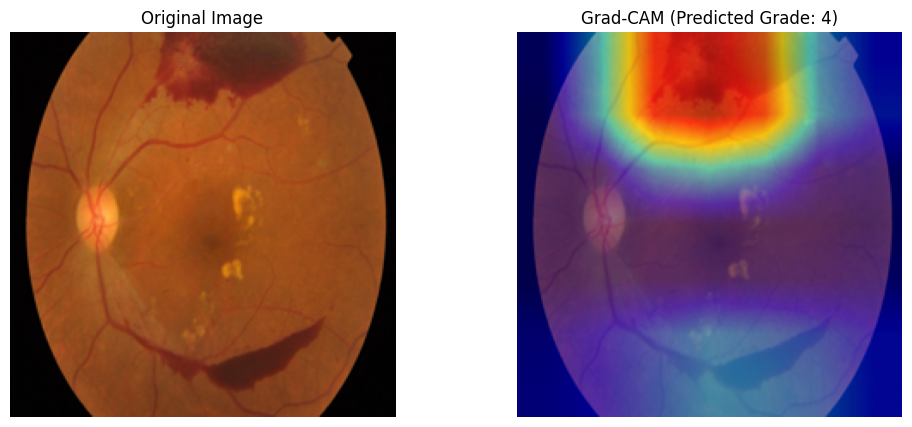

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title(f"Grad-CAM (Predicted Grade: {predicted_class.item()})")
plt.axis("off")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
save_path = "/content/drive/MyDrive/DiabeticRetinopathy/best_densenet121.pth"
torch.save(model3.state_dict(),save_path)

In [ ]:
print(f"Model saved successfully at:\n{save_path}")

Model saved successfully at:
/content/drive/MyDrive/DiabeticRetinopathy/best_densenet121.pth


In [ ]:
import os

print(os.path.exists(save_path))

True
